# Análise Exploratória do Dataset IBC Municípios

Este notebook realiza uma análise exploratória do dataset **IBC_municipios_indicadores_normalizados.csv**, que contém indicadores do Índice Brasileiro de Conectividade (IBC) por município.  
Os dados foram obtidos do portal [dados.gov.br](https://dados.gov.br/dados/conjuntos-dados/meu-municipio---indice-brasileiro-de-conectividade).

O dataset inclui informações como:
- Ano
- Código do Município
- Nome do Município
- UF
- Índice Brasileiro de Conectividade (IBC)
- Cobertura Populacional 4G/5G
- Densidade SMP (Serviço Móvel Pessoal)
- HHI SMP (Índice de Herfindahl-Hirschman para SMP)
- Densidade SCM (Serviço de Comunicação Multimídia)
- HHI SCM
- Adensamento de Estações
- Fibra
- Cobertura da Área Agricultável

O objetivo é compreender padrões e relações entre esses indicadores, além de responder perguntas relevantes sobre conectividade nos municípios brasileiros.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Carregamento dos dados
df = pd.read_csv("../data/raw/IBC_municipios_indicadores_normalizados.csv", sep=';', encoding='utf-8')

# Visualização inicial
df.head()


,Ano,Código Município,Município,UF,IBC,Cobertura Pop. 4G5G,Densidade SMP,HHI SMP,Densidade SCM,HHI SCM,Adensamento Estações,Fibra,Cobertura área agricultável
0,2024,1100015,Alta Floresta D'Oeste - RO,RO,"29,45","64,9073","48,18",44,"10,26",73,"13,13",0,"8,9309"
1,2024,1100023,Ariquemes - RO,RO,"55,80","86,0454","60,08",51,"39,64",78,"13,36",100,"12,1568"
2,2024,1100031,Cabixi - RO,RO,"26,58","48,2041","44,78",35,"38,97",10,"17,57",0,"13,3981"
3,2024,1100049,Cacoal - RO,RO,"59,87","82,1237","63,77",56,"60,32",78,"13,83",100,"18,4630"
4,2024,1100056,Cerejeiras - RO,RO,"45,08","88,5058","68,41",49,"25,83",48,"14,73",50,"9,6841"


In [35]:
# Renomear colunas para remover caracteres especiais
df.columns = ['Ano','Codigo_Municipio','Municipio','UF','IBC','Cobertura_Pop_4G5G','Densidade_SMP','HHI_SMP','Densidade_SCM','HHI_SCM','Adensamento_Estacoes','Fibra','Cobertura_Area_Agricultavel']

# Converter colunas numéricas (substituir vírgula por ponto)
for col in ['IBC','Cobertura_Pop_4G5G','Densidade_SMP','HHI_SMP','Densidade_SCM','HHI_SCM','Adensamento_Estacoes','Fibra','Cobertura_Area_Agricultavel']:
    df[col] = df[col].astype(str).str.replace(',','.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verificar valores faltantes
df.isnull().sum()


Ano                                0
Codigo_Municipio                   0
Municipio                          0
UF                                 0
IBC                                0
Cobertura_Pop_4G5G                 0
Densidade_SMP                      0
HHI_SMP                            0
Densidade_SCM                      0
HHI_SCM                            0
Adensamento_Estacoes               0
Fibra                              0
Cobertura_Area_Agricultavel    16723
dtype: int64

In [36]:
# Imputação simples: preencher valores faltantes com a mediana da coluna
for col in ['Cobertura_Area_Agricultavel']:
    df[col] = df[col].fillna(df[col].median())

# Verificar novamente
df.isnull().sum()


Ano                            0
Codigo_Municipio               0
Municipio                      0
UF                             0
IBC                            0
Cobertura_Pop_4G5G             0
Densidade_SMP                  0
HHI_SMP                        0
Densidade_SCM                  0
HHI_SCM                        0
Adensamento_Estacoes           0
Fibra                          0
Cobertura_Area_Agricultavel    0
dtype: int64

In [37]:
# === Mapeamento de UF para Região do Brasil ===
mapa_regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

# Criar coluna de região
df["Regiao"] = df["UF"].map(mapa_regioes)

In [38]:
# Estatísticas descritivas
df.describe(include='all')


,Ano,Codigo_Municipio,Municipio,UF,IBC,Cobertura_Pop_4G5G,Densidade_SMP,HHI_SMP,Densidade_SCM,HHI_SCM,Adensamento_Estacoes,Fibra,Cobertura_Area_Agricultavel,Regiao
count,22280.000000,2.228000e+04,22280,22280,22280.000000,22280.000000,22280.000000,22280.000000,22280.000000,22280.000000,22280.000000,22280.000000,22280.000000,22280
unique,NaN,NaN,5570,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,Alta Floresta D'Oeste - RO,MG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nordeste
freq,NaN,NaN,4,3412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7176
mean,2022.500000,3.253591e+06,NaN,NaN,51.906346,80.004675,59.923873,47.390619,16.617638,56.186131,16.150221,76.216338,61.997978,NaN
std,1.118059,9.848440e+05,NaN,NaN,13.865064,18.047806,19.343919,25.059560,17.417516,20.941347,14.837588,40.896435,15.857661,NaN
min,2021.000000,1.100015e+06,NaN,NaN,9.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2021.750000,2.512101e+06,NaN,NaN,43.140000,68.548075,46.220000,27.000000,3.850000,43.000000,6.700000,50.000000,62.991400,NaN
50%,2022.500000,3.146280e+06,NaN,NaN,54.310000,84.711650,60.180000,50.000000,11.490000,60.000000,11.240000,100.000000,62.991400,NaN
75%,2023.250000,4.119202e+06,NaN,NaN,62.292500,95.494500,74.562500,67.000000,23.330000,72.000000,20.050000,100.000000,62.991400,NaN


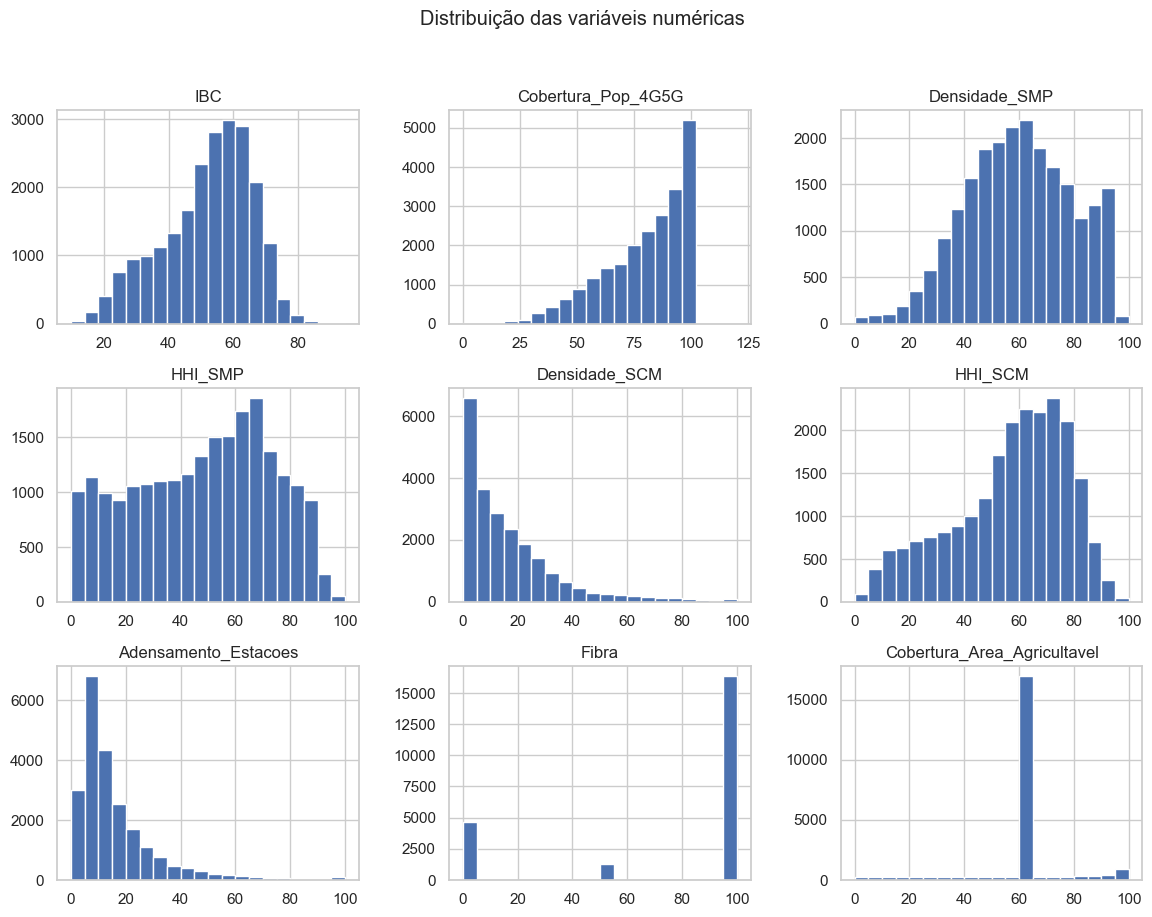

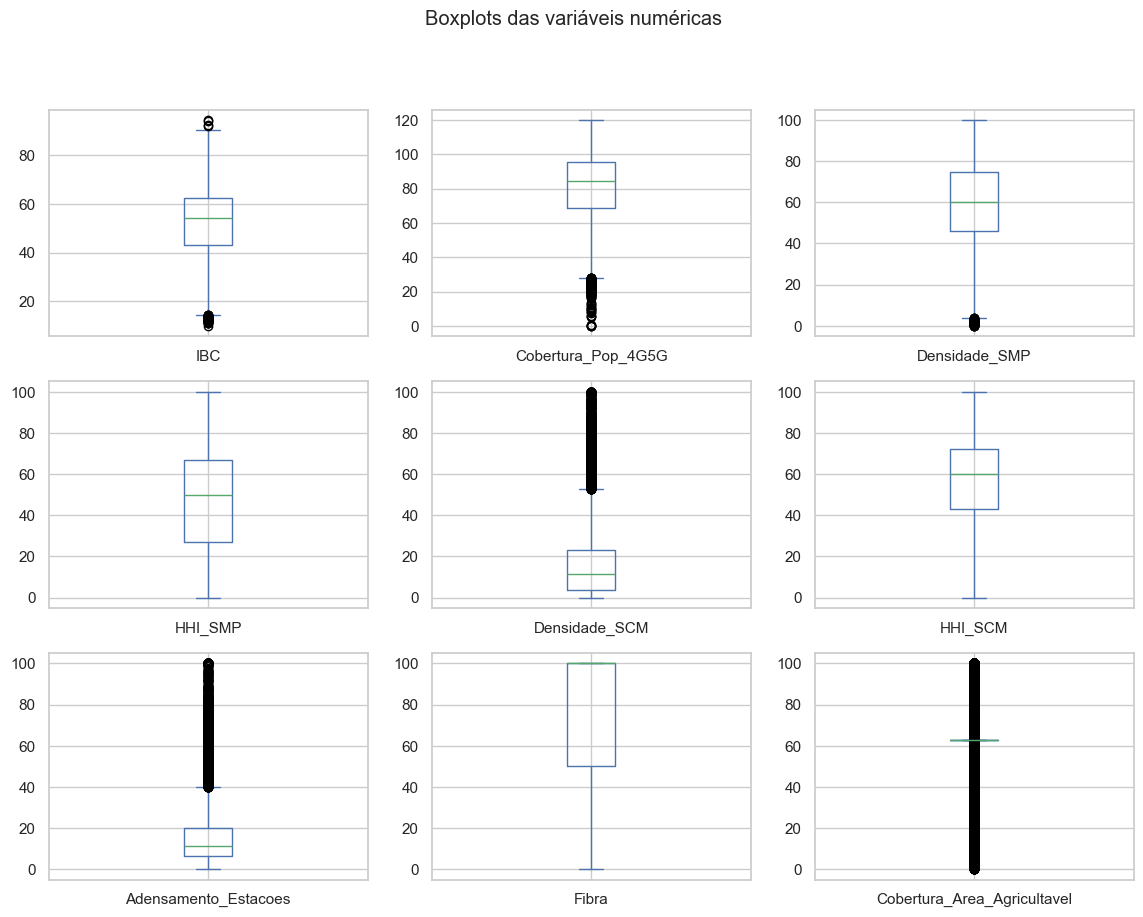

In [39]:
# Histograma das variáveis numéricas
num_cols = ['IBC','Cobertura_Pop_4G5G','Densidade_SMP','HHI_SMP','Densidade_SCM','HHI_SCM','Adensamento_Estacoes','Fibra','Cobertura_Area_Agricultavel']
df[num_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Distribuição das variáveis numéricas")
plt.show()

# Boxplots
df[num_cols].plot(kind='box', subplots=True, layout=(3,3), figsize=(14,10))
plt.suptitle("Boxplots das variáveis numéricas")
plt.show()


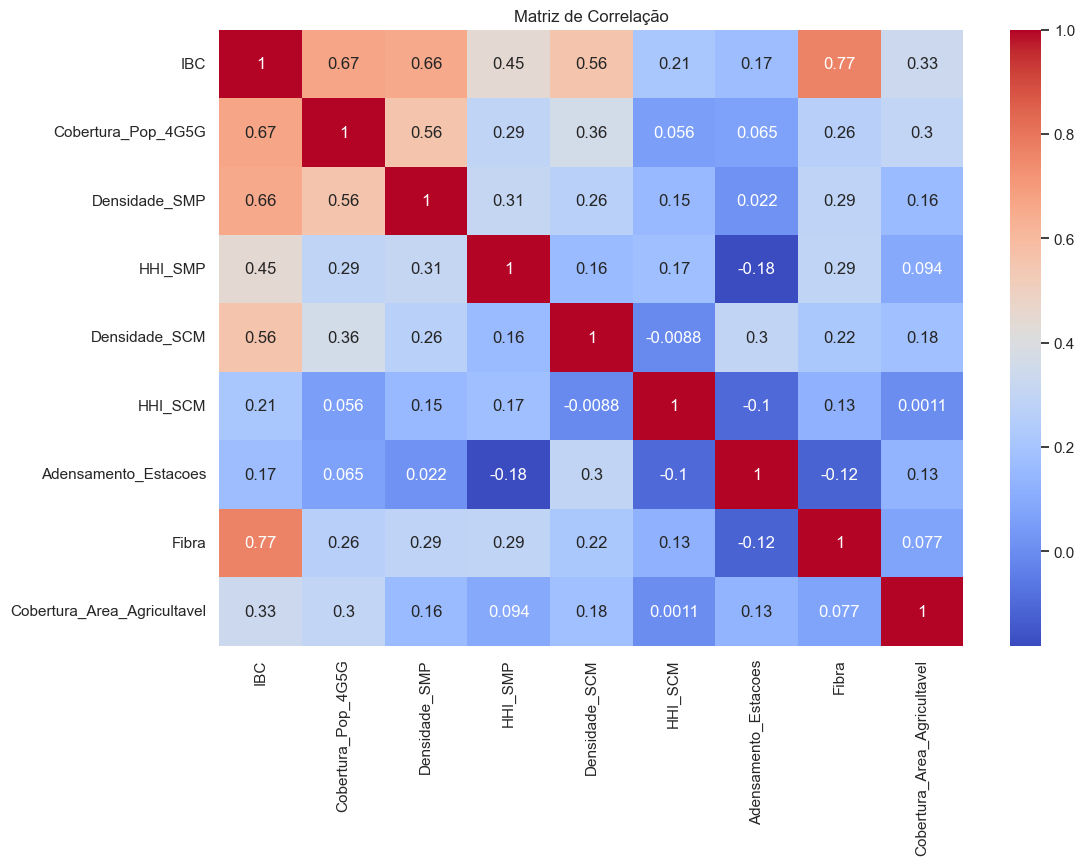

In [40]:
# Matriz de correlação
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()


### Primeira Pergunta: Há relação entre o Estado do município e o IBC?
Pela a análise dos gráficos abaixo, podemos perceber que nos Estados com maiores cidade como Rio de Janeiro e São Paulo, apresentam melhores Indices de IBC médio. Enquanto estados mais interioranos como Amapá e Roraima, apresentam indices menores.

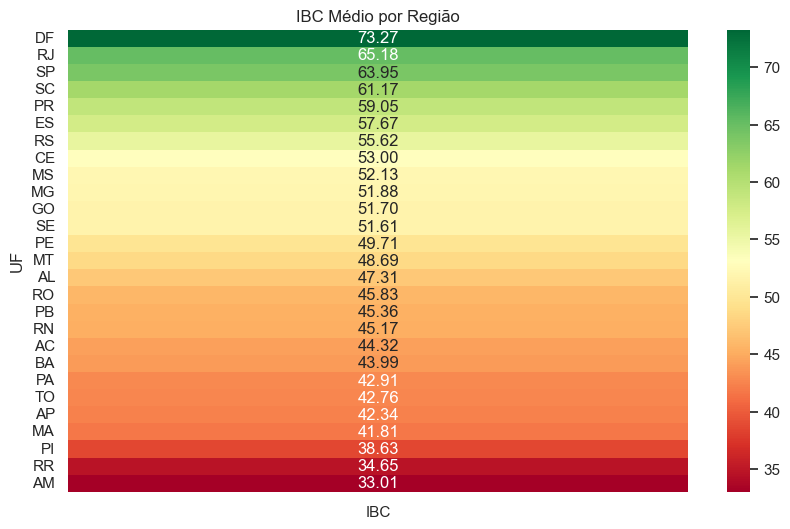

In [41]:
# Agrupar por região
ibc_por_regiao = df.groupby('UF')['IBC'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(ibc_por_regiao.to_frame(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('IBC Médio por Região')
plt.show()

### Segunda Pergunta: Há relação entre a Região do município e a cobertura 4/5G?
Pela a análise dos gráficos abaixo, podemos perceber que nas regiões com maiores cidade como Sul e suldeste, apresentam maiores indices de cobertura 4G e 5G. Enquanto regiões mais interioras como Norte e Nordeste, apresentam indices menores.

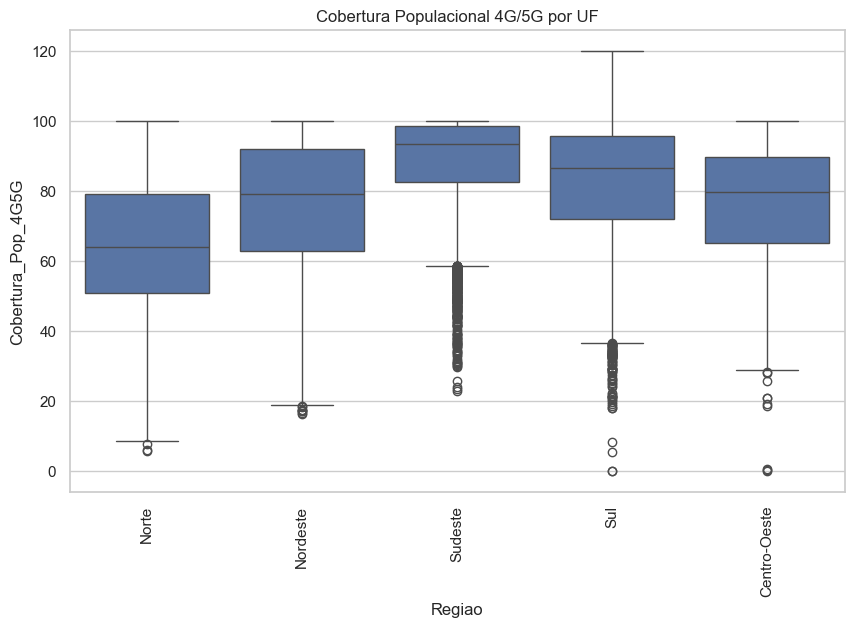

In [44]:
sns.boxplot(x='Regiao', y='Cobertura_Pop_4G5G', data=df)
plt.xticks(rotation=90)
plt.title("Cobertura Populacional 4G/5G por UF")
plt.show()


### Terceira Pergunta: Municípios com maior densidade SMP também apresentam maior densidade SCM?
Visualmente, há uma tendência de crescimento da Densidade_SCM conforme a Densidade_SMP aumenta — mas a nuvem é bem espalhada. Assim indica uma correlação positiva, mas não muito forte.

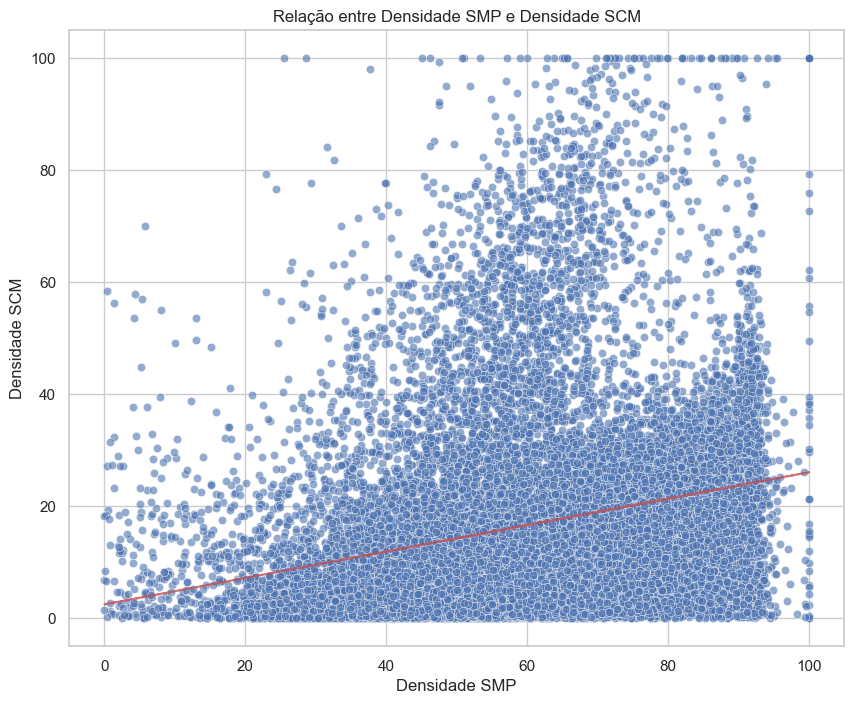

In [45]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Densidade_SMP', y='Densidade_SCM', alpha=0.6)
plt.title('Relação entre Densidade SMP e Densidade SCM')
plt.xlabel('Densidade SMP')
plt.ylabel('Densidade SCM')

# Adicionar linha de tendência
z = np.polyfit(df['Densidade_SMP'], df['Densidade_SCM'], 1)
p = np.poly1d(z)
plt.plot(df['Densidade_SMP'], p(df['Densidade_SMP']), "r--", alpha=0.8)

plt.show()


### Quarta Pergunta: Como o IBC evoluiu ao longo dos anos em cada região do Brasil?
Podemos perceber que o IBC apresenta trajetórias distintas entre as regiões ao longo dos anos, mas, de modo geral, há uma tendência de crescimento moderado entre 2021 e 2024 em algumas regiões.

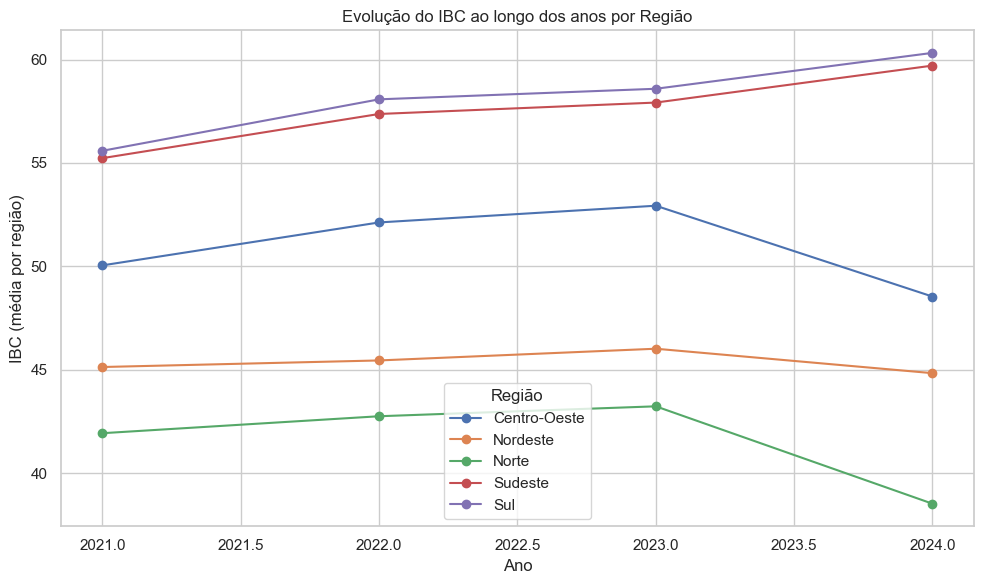

In [46]:
df_grouped = (
    df.groupby(["Ano", "Regiao"])["IBC"]
      .mean()
      .reset_index()
)

# Lista de regiões disponíveis
regioes = df_grouped["Regiao"].unique()

plt.figure(figsize=(10, 6))

# Plota uma linha para cada região
for regiao in regioes:
    dados_regiao = df_grouped[df_grouped["Regiao"] == regiao]
    plt.plot(
        dados_regiao["Ano"],
        dados_regiao["IBC"],
        marker="o",
        label=regiao
    )

plt.xlabel("Ano")
plt.ylabel("IBC (média por região)")
plt.title("Evolução do IBC ao longo dos anos por Região")
plt.legend(title="Região")
plt.grid(True)
plt.tight_layout()
plt.show()

### Quinta Pergunta: Existe correlação entre Cobertura da Área Agricultável e IBC?
Os pontos estão distribuídos com uma tendência ascendente, o que sugere uma correlação positiva entre os dois indicadores. Assim podemos deduzir que quanto maior a cobertura da área agricultável, maior tende a ser o IBC.

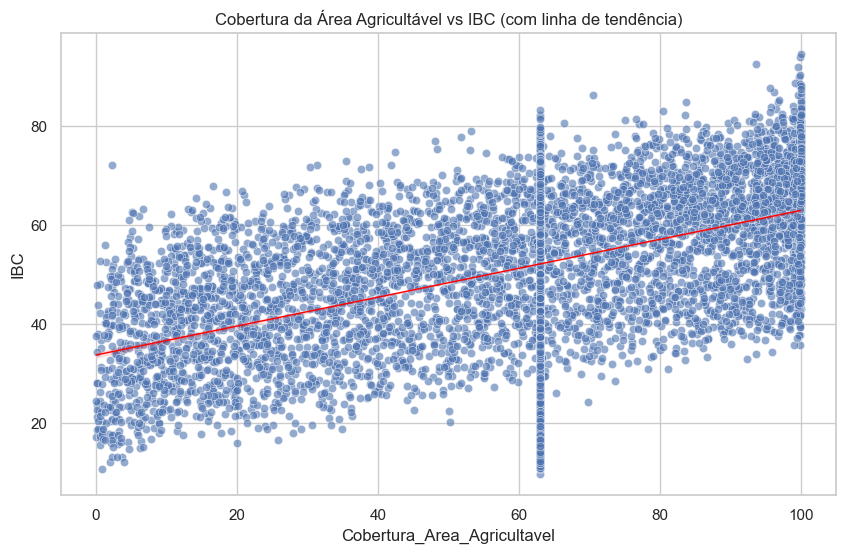

In [49]:
# Scatterplot original
sns.scatterplot(
    x='Cobertura_Area_Agricultavel',
    y='IBC',
    data=df,
    alpha=0.6
)

# Linha de tendência (regressão linear simples)
sns.regplot(
    x='Cobertura_Area_Agricultavel',
    y='IBC',
    data=df,
    scatter=False,
    line_kws={'color': 'red', 'linewidth': 1}
)

plt.title("Cobertura da Área Agricultável vs IBC (com linha de tendência)")
plt.xlabel("Cobertura_Area_Agricultavel")
plt.ylabel("IBC")

plt.show()

### Sexta pergunta: Quais estados apresentam maior concentração de municípios com IBC acima da mediana?
Assim como a análise da Região, ao observarmos mais a fundo o IBC por estados, podemos ver que os estados com maior destaque são os estados de São Paulo e Rio de janeiro, que contém as maiores cidades do País. Os estados do Sul tem maior contingente percentual relacionados a conectividade.

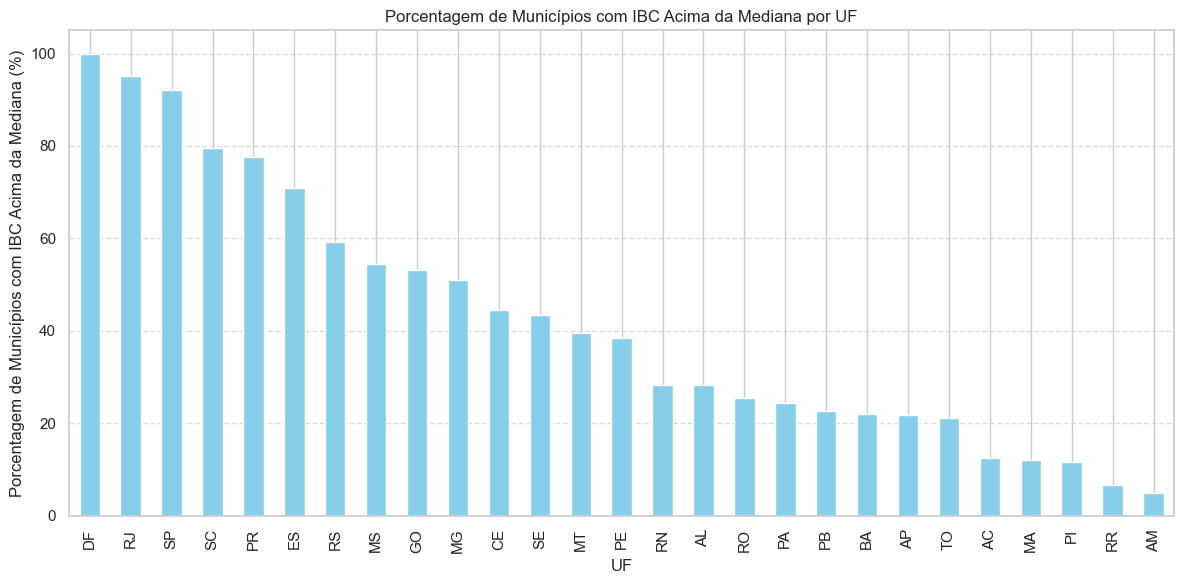

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Calcular a mediana do IBC
median_ibc = df['IBC'].median()

# Criar coluna booleana indicando se o município está acima da mediana
df['IBC_Acima_Mediana'] = df['IBC'] > median_ibc

# Agrupar por UF e calcular a porcentagem de municípios acima da mediana
porcentagem_por_uf = (
    df.groupby('UF')['IBC_Acima_Mediana']
    .mean()
    .sort_values(ascending=False) * 100
)

# Plotar gráfico de barras
plt.figure(figsize=(12,6))
porcentagem_por_uf.plot(kind='bar', color='skyblue')
plt.ylabel("Porcentagem de Municípios com IBC Acima da Mediana (%)")
plt.title("Porcentagem de Municípios com IBC Acima da Mediana por UF")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

